In [1]:
# Loading the Laptop dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/laptop.csv")

In [2]:
# Shape of the dataset
df.shape

(1303, 13)

In [3]:
# Checking the data type of each column whether null values present or not
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      1303 non-null   int64  
 1   Unnamed: 0        1273 non-null   float64
 2   Company           1273 non-null   object 
 3   TypeName          1273 non-null   object 
 4   Inches            1273 non-null   object 
 5   ScreenResolution  1273 non-null   object 
 6   Cpu               1273 non-null   object 
 7   Ram               1273 non-null   object 
 8   Memory            1273 non-null   object 
 9   Gpu               1273 non-null   object 
 10  OpSys             1273 non-null   object 
 11  Weight            1273 non-null   object 
 12  Price             1273 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [4]:
# looking at the data inside the table
df.head()

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
# count of the null values in each column
df.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

<Axes: >

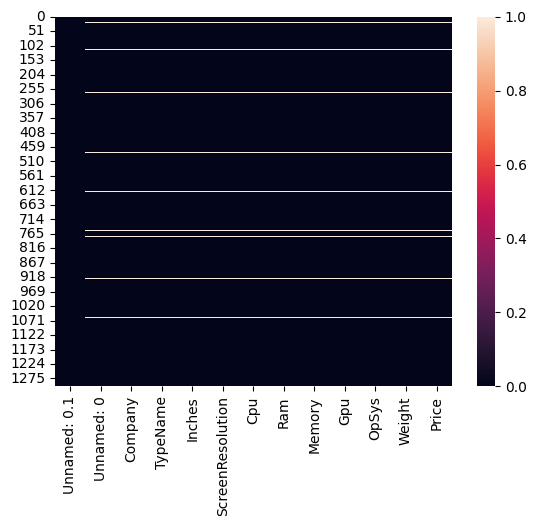

In [6]:
# null values in Graph
import seaborn as sns
sns.heatmap(df.isnull())

In [7]:
# removing the null rows and checking the count of null values again
df=df.dropna()
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

<Axes: >

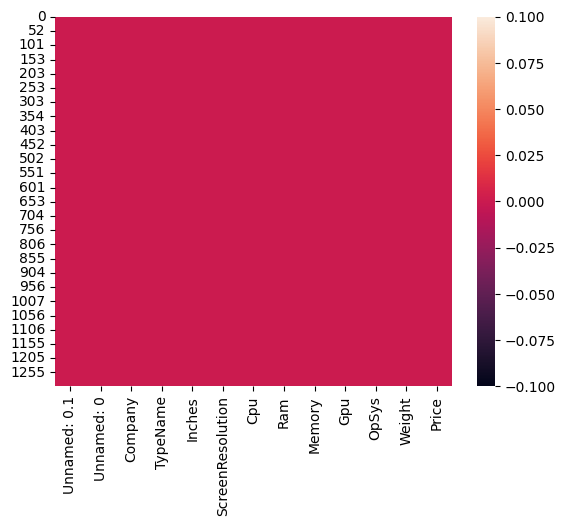

In [8]:
import seaborn as sns
sns.heatmap(df.isnull())

In [9]:
df.drop(columns=["Unnamed: 0.1","Unnamed: 0"],axis=1,inplace=True)
df.shape

(1273, 11)

In [10]:
df["Company"]=df["Company"].str.strip()
df["TypeName"]=df["TypeName"].str.strip()
df["Inches"]=df["Inches"].str.strip()
df["ScreenResolution"]=df["ScreenResolution"].str.strip()
df["Cpu"]=df["Cpu"].str.strip()
df["Ram"]=df["Ram"].str.strip()
df["Memory"]=df["Memory"].str.strip()
df["Gpu"]=df["Gpu"].str.strip()
df["Weight"]=df["Weight"].str.strip()


In [11]:
df["Pixels"]=df["ScreenResolution"].str.extract(r'(\d+x\d+)')
df["DisplayType"]=df["ScreenResolution"].str.extract(r'([A-Za-z\s]+)')
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Pixels,DisplayType
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560x1600,IPS Panel Retina Display
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440x900,x
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920x1080,Full HD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880x1800,IPS Panel Retina Display
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560x1600,IPS Panel Retina Display


In [12]:
df["DisplayType"].value_counts()

DisplayType
Full HD                      540
x                            307
IPS Panel Full HD            283
Touchscreen                   34
IPS Panel                     34
IPS Panel Retina Display      17
Quad HD                       17
K Ultra HD                    16
IPS Panel Touchscreen         14
IPS Panel Quad HD             11
Name: count, dtype: int64

In [13]:
df['DisplayType'] = df['DisplayType'].replace('x', df["DisplayType"].mode()[0])
df["DisplayType"].value_counts()

DisplayType
Full HD                      847
IPS Panel Full HD            283
Touchscreen                   34
IPS Panel                     34
IPS Panel Retina Display      17
Quad HD                       17
K Ultra HD                    16
IPS Panel Touchscreen         14
IPS Panel Quad HD             11
Name: count, dtype: int64

In [14]:
df["Pixels"]=df["Pixels"].str.replace("x"," ")
df["Length"]=df["Pixels"].str.split().str[0].astype(int)
df["Breadth"]=df["Pixels"].str.split().str[1].astype(int)

In [15]:
df.dtypes

Company              object
TypeName             object
Inches               object
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
Pixels               object
DisplayType          object
Length                int64
Breadth               int64
dtype: object

In [16]:
df["Inches"]=df["Inches"].replace("?",df["Inches"].mode()[0]).astype(float)

In [17]:
df["PPI"]=round((np.sqrt(df["Length"]**2+df["Breadth"]**2))/df["Inches"],2)
df.tail()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Pixels,DisplayType,Length,Breadth,PPI
1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64,1920 1080,IPS Panel Full HD,1920,1080,157.35
1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72,3200 1800,IPS Panel Quad HD,3200,1800,276.05
1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12,1366 768,Full HD,1366,768,111.94
1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92,1366 768,Full HD,1366,768,100.45
1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32,1366 768,Full HD,1366,768,100.45


In [18]:
df["Cpu_Manufacturer"] = df["Cpu"].str.split().str[0]
df["Cpu_Manufacturer"].value_counts()

Cpu_Manufacturer
Intel      1210
AMD          62
Samsung       1
Name: count, dtype: int64

In [19]:
df = df[df["Cpu_Manufacturer"] != "Samsung"]
df["Cpu_Manufacturer"].str.strip().unique()

array(['Intel', 'AMD'], dtype=object)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1272 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1272 non-null   object 
 1   TypeName          1272 non-null   object 
 2   Inches            1272 non-null   float64
 3   ScreenResolution  1272 non-null   object 
 4   Cpu               1272 non-null   object 
 5   Ram               1272 non-null   object 
 6   Memory            1272 non-null   object 
 7   Gpu               1272 non-null   object 
 8   OpSys             1272 non-null   object 
 9   Weight            1272 non-null   object 
 10  Price             1272 non-null   float64
 11  Pixels            1272 non-null   object 
 12  DisplayType       1272 non-null   object 
 13  Length            1272 non-null   int64  
 14  Breadth           1272 non-null   int64  
 15  PPI               1272 non-null   float64
 16  Cpu_Manufacturer  1272 non-null   object 
dtype

In [21]:
import warnings
warnings.filterwarnings("ignore")
df['CpuCoreSeries'] = df['Cpu'].str.extract(r'(?:Intel|AMD)\s+((?:Core i[357]|Core M|E-Series|Atom|A[4689]-Series|A12-Series|A10-Series|Celeron Quad Core|Celeron Dual Core|Ryzen|FX|Pentium Quad Core|Xeon|Pentium Dual Core))')

In [22]:
df["CpuCoreSeries"].isnull().sum()

0

In [23]:
df["CpuCoreSeries"].value_counts().astype(str)

CpuCoreSeries
Core i7              515
Core i5              410
Core i3              134
Celeron Dual Core     79
Pentium Quad Core     27
Core M                19
A9-Series             17
Atom                  11
A6-Series             11
E-Series               9
Celeron Quad Core      8
A12-Series             8
A10-Series             6
A8-Series              4
Ryzen                  4
Xeon                   4
Pentium Dual Core      3
FX                     2
A4-Series              1
Name: count, dtype: object

In [24]:
df["CpuFrequencyGHz"]=df["Cpu"].str.extract(r'(\d+(?:\.\d+)?)GHz')

In [25]:
df["CpuFrequencyGHz"]=df["CpuFrequencyGHz"].str.replace("GHz","")

In [26]:
df["CpuFrequencyGHz"]=df["CpuFrequencyGHz"].astype(float)
df["CpuFrequencyGHz"].unique()

array([2.3 , 1.8 , 2.5 , 2.7 , 3.1 , 3.  , 2.2 , 1.6 , 2.  , 2.8 , 1.2 ,
       2.9 , 2.4 , 1.5 , 1.9 , 1.44, 1.1 , 1.3 , 2.6 , 3.6 , 3.2 , 1.  ,
       2.1 , 0.9 , 1.92])

In [27]:
df["GpuManufacturer"] = df["Gpu"].str.split(" ",n=1).str[0]
df["GpuManufacturer"].value_counts()

GpuManufacturer
Intel     703
Nvidia    393
AMD       176
Name: count, dtype: int64

In [28]:
df["Gpu"]=df["Gpu"].str.replace("-"," ")
# Function to extract middle part after removing first and last words
def extract_middle_part(gpu_name):
    words = gpu_name.split()
    middle_part = ' '.join(words[1:-1])
    return middle_part

# Apply the function to each GPU name
df['GpuType'] = df['Gpu'].apply(extract_middle_part)

df['GpuType'].value_counts()

GpuType
HD Graphics           593
GeForce GTX           204
GeForce               124
Radeon                 77
UHD Graphics           66
Radeon R5              42
Quadro                 31
HD                     29
GeForce GTX 1050       27
Radeon R7              25
Radeon RX              12
Iris Plus Graphics     10
GeForce GT              5
FirePro                 5
Radeon R4               5
Radeon R2               4
Iris Graphics           3
Radeon Pro              3
R4                      1
GTX 980                 1
R17M M1                 1
Iris Pro                1
GeForce GTX1050         1
Graphics                1
Radeon R9               1
Name: count, dtype: int64

In [29]:
df['GpuType'].unique()

array(['Iris Plus Graphics', 'HD Graphics', 'Radeon Pro', 'Radeon',
       'Iris Pro', 'GeForce', 'UHD Graphics', 'Radeon R5', 'GeForce GTX',
       'HD', 'Iris Graphics', 'Radeon RX', 'Radeon R4',
       'GeForce GTX 1050', 'R4', 'Radeon R7', 'GTX 980', 'R17M M1',
       'Quadro', 'FirePro', 'GeForce GT', 'GeForce GTX1050', 'Radeon R2',
       'Graphics', 'Radeon R9'], dtype=object)

In [30]:
df["StorageDevice"] = df["Memory"].str.extract(r"(HDD|SSD|Flash Storage|Hybrid)\b")

In [31]:
df["Memory"] = df["Memory"].str.split().str[0]
# Display the DataFram
df["Memory"].unique()

array(['128GB', '256GB', '512GB', '500GB', '1TB', '64GB', '32GB', '2TB',
       '1.0TB', '16GB', '180GB', '?', '240GB', '8GB', '508GB'],
      dtype=object)

In [32]:
df["Memory"]=df["Memory"].replace("?",df["Memory"].mode()[0])
df["Memory"].unique()

array(['128GB', '256GB', '512GB', '500GB', '1TB', '64GB', '32GB', '2TB',
       '1.0TB', '16GB', '180GB', '240GB', '8GB', '508GB'], dtype=object)

In [33]:
df["Price"]=round(df["Price"],2)
df["Price"]

0        71378.68
1        47895.52
2        30636.00
3       135195.34
4        96095.81
          ...    
1298     33992.64
1299     79866.72
1300     12201.12
1301     40705.92
1302     19660.32
Name: Price, Length: 1272, dtype: float64

In [34]:
df.corr(numeric_only=True)["Price"].sort_values(ascending=False)

Price              1.000000
Length             0.558419
Breadth            0.555899
PPI                0.470572
CpuFrequencyGHz    0.428794
Inches             0.044252
Name: Price, dtype: float64

Display Type

In [35]:
df["Display_Type"]=df["DisplayType"].str.strip().replace("IPS Panel Touchscreen","Touchscreen")
df["Display_Type"].value_counts()

Display_Type
Full HD                     847
IPS Panel Full HD           283
Touchscreen                  47
IPS Panel                    34
IPS Panel Retina Display     17
Quad HD                      17
K Ultra HD                   16
IPS Panel Quad HD            11
Name: count, dtype: int64

In [36]:
def DisplayTypeNames(name):
    valid_names = {"Full HD", "IPS Panel Full HD", "Touchscreen", "IPS Panel", "K Ultra HD"}
    if name not in valid_names:
        return "IPS Panel"
    else:
        return name

# Apply the function to the Company column
df["Display_Type"] = df["Display_Type"].apply(DisplayTypeNames)
df["Display_Type"].value_counts()

Display_Type
Full HD              847
IPS Panel Full HD    283
IPS Panel             79
Touchscreen           47
K Ultra HD            16
Name: count, dtype: int64

In [37]:
df["Display"]=df["Display_Type"].copy()

<Axes: xlabel='Price', ylabel='Display_Type'>

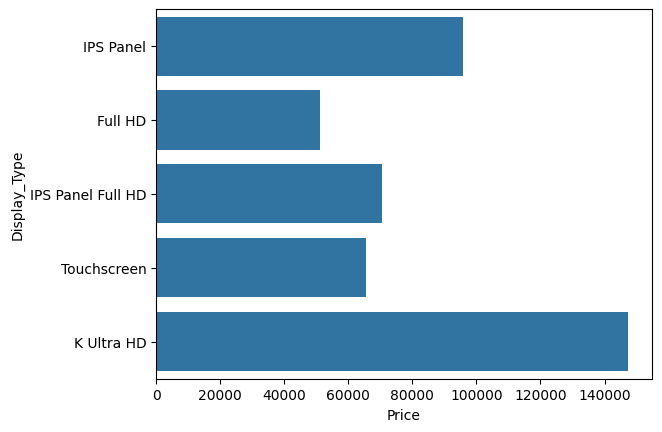

In [38]:
sns.barplot(df, y="Display_Type", x="Price", errorbar=None)

Laptop Company

<Axes: xlabel='Price', ylabel='Company'>

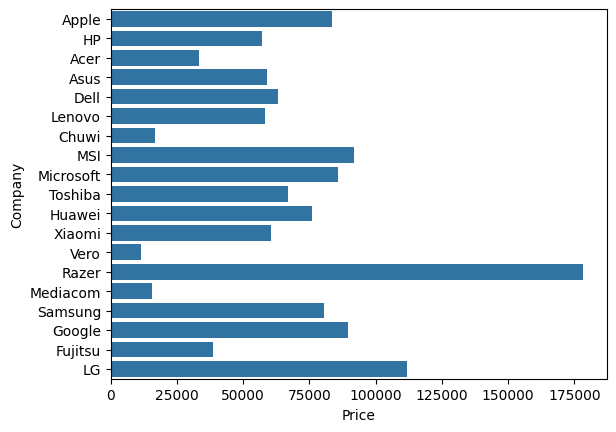

In [39]:
sns.barplot(df, y="Company", x="Price", errorbar=None)

In [40]:
df["Company"].value_counts()

Company
Lenovo       290
Dell         287
HP           266
Asus         156
Acer         103
MSI           53
Toshiba       47
Apple         21
Samsung        8
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
LG             3
Huawei         2
Fujitsu        2
Name: count, dtype: int64

In [41]:
def CompanyNames(name):
    valid_names = {"Lenovo", "Dell", "HP", "Asus", "Acer", "Apple", "MSI", "Razer"}
    if name not in valid_names:
        return "Others"
    else:
        return name

# Apply the function to the Company column
df["CompanyName"] = df["Company"].apply(CompanyNames)
df["CompanyName"].value_counts()

CompanyName
Lenovo    290
Dell      287
HP        266
Asus      156
Acer      103
Others     89
MSI        53
Apple      21
Razer       7
Name: count, dtype: int64

Type of Laptop

In [42]:
df = df.rename(columns={'TypeName': 'Laptop_Type'})

In [43]:
df["Laptop_Type"].value_counts()

Laptop_Type
Notebook              710
Gaming                203
Ultrabook             191
2 in 1 Convertible    115
Workstation            29
Netbook                24
Name: count, dtype: int64

OpSystem in Laptop

In [44]:
df["OpSys"].value_counts()

OpSys
Windows 10      1047
No OS             63
Linux             61
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

In [45]:
df= df[df["OpSys"]!="Android"]
df["OpSys"].value_counts()

OpSys
Windows 10      1047
No OS             63
Linux             61
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Name: count, dtype: int64

Weight of Laptop

In [46]:
# Changing data type of Weight column to numeric
df["WeightKg"]=df["Weight"].str.replace("kg"," ")
df["WeightKg"].unique()

array(['1.37 ', '1.34 ', '1.86 ', '1.83 ', '2.1 ', '2.04 ', '1.3 ',
       '1.6 ', '2.2 ', '0.92 ', '1.22 ', '2.5 ', '1.62 ', '1.91 ', '2.3 ',
       '1.35 ', '1.88 ', '1.89 ', '1.65 ', '2.71 ', '1.2 ', '1.44 ',
       '2.8 ', '2 ', '2.65 ', '2.77 ', '3.2 ', '1.49 ', '2.4 ', '2.13 ',
       '2.43 ', '1.7 ', '1.4 ', '1.8 ', '1.9 ', '3 ', '1.252 ', '2.7 ',
       '2.02 ', '1.63 ', '1.96 ', '1.21 ', '2.45 ', '1.25 ', '1.5 ',
       '2.62 ', '1.38 ', '1.58 ', '1.85 ', '1.23 ', '2.16 ', '2.36 ',
       '7.2 ', '2.05 ', '1.32 ', '1.75 ', '0.97 ', '2.56 ', '1.48 ',
       '1.74 ', '1.1 ', '1.56 ', '2.03 ', '1.05 ', '5.4 ', '4.4 ',
       '1.90 ', '1.29 ', '2.0 ', '1.95 ', '2.06 ', '1.12 ', '3.49 ',
       '3.35 ', '2.23 ', '?', '2.9 ', '4.42 ', '2.69 ', '2.37 ', '4.7 ',
       '3.6 ', '2.08 ', '4.3 ', '1.68 ', '1.41 ', '4.14 ', '2.18 ',
       '2.24 ', '2.67 ', '4.1 ', '2.14 ', '1.36 ', '2.25 ', '2.15 ',
       '2.19 ', '2.54 ', '3.42 ', '5.8 ', '1.28 ', '2.33 ', '1.45 ',
       '2.79 ', '8.2

In [47]:
# Changing data type of Weight column to numeric
df["WeightKg"]=df["WeightKg"].replace("?",df["WeightKg"].mode()[0]).astype(float)
df["WeightKg"].value_counts().get("?",0)

0

Pixel per Inch(PPI)

<Axes: xlabel='PPI', ylabel='Price'>

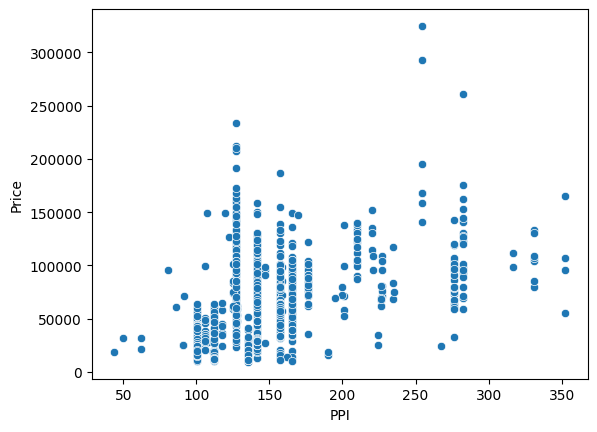

In [48]:
sns.scatterplot(df, x="PPI", y="Price")

In [49]:
q1=df.describe()["PPI"]["25%"]
q3=df.describe()["PPI"]["75%"]
IQR=q3-q1
ll=q1-(1.5*IQR)
ul=q3+(1.5*IQR)
df["PPI"]=df["PPI"].clip(ll,ul)
df["PPI"].unique()

array([202.365, 127.68 , 141.21 , 100.45 , 157.35 , 165.63 , 127.34 ,
       111.94 ,  90.58 , 200.84 , 199.69 , 119.72 , 106.11 , 158.48 ,
       135.09 , 117.83 , 176.23 ,  86.05 ,  82.325, 107.59 , 189.91 ,
       122.38 , 125.37 ,  91.79 , 107.99 , 161.73 , 146.86 , 111.14 ,
       169.78 , 194.95 ])

CPU and GPU Manufacturers

<Axes: xlabel='GpuManufacturer', ylabel='Price'>

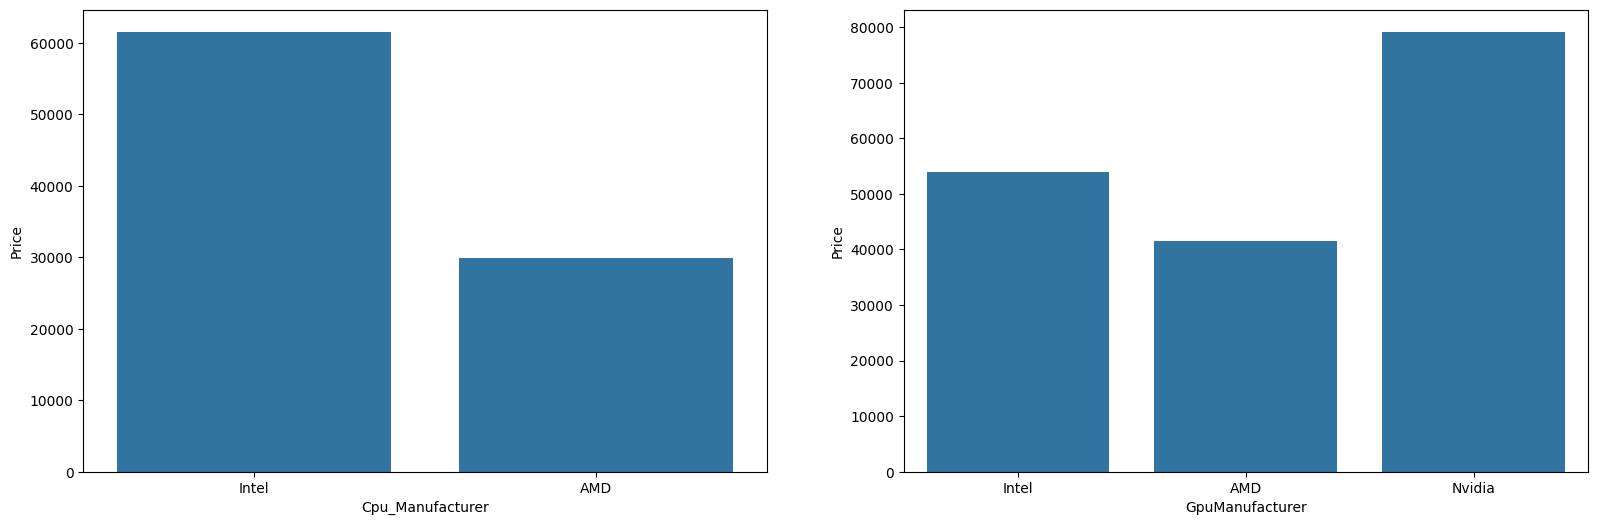

In [50]:
plt.figure(figsize=(30,6))
plt.subplot(1,3,1)
sns.barplot(df, y="Price", x="Cpu_Manufacturer", errorbar=None)
plt.subplot(1,3,2)
sns.barplot(df, y="Price", x="GpuManufacturer", errorbar=None)

CPU Core or Series

<Axes: xlabel='Price', ylabel='CpuCoreSeries'>

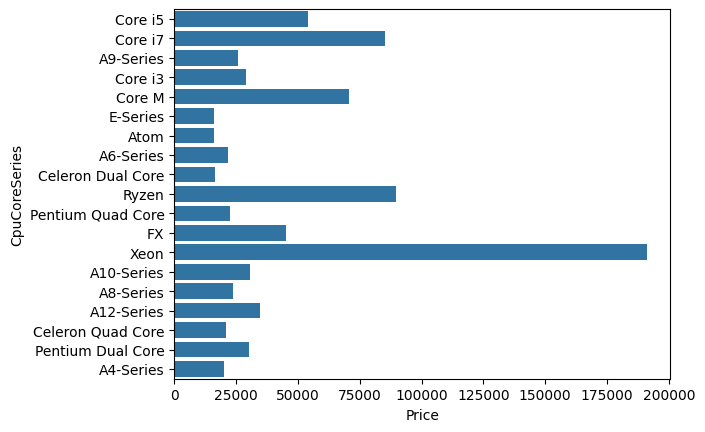

In [51]:
sns.barplot(df, y="CpuCoreSeries", x="Price", errorbar=None)

In [52]:
df["CpuCoreSeries"].value_counts()

CpuCoreSeries
Core i7              515
Core i5              410
Core i3              134
Celeron Dual Core     79
Pentium Quad Core     27
Core M                19
A9-Series             17
A6-Series             11
Atom                  10
E-Series               9
Celeron Quad Core      8
A12-Series             8
A10-Series             6
A8-Series              4
Ryzen                  4
Xeon                   4
Pentium Dual Core      3
FX                     2
A4-Series              1
Name: count, dtype: int64

In [53]:
def CoreNames(name):
    valid_names = {"Core i3", "Core i5", "Core i7", "Celeron Dual Core", "Xeon", "Core M", "Ryzen", "A12-Series"}
    if name not in valid_names:
        return "Others"
    else:
        return name

# Apply the function to the Company column
df["CpuCore"] = df["CpuCoreSeries"].apply(CoreNames)
df["CpuCore"].value_counts()

CpuCore
Core i7              515
Core i5              410
Core i3              134
Others                98
Celeron Dual Core     79
Core M                19
A12-Series             8
Ryzen                  4
Xeon                   4
Name: count, dtype: int64

GPU type

<Axes: xlabel='Price', ylabel='GpuType'>

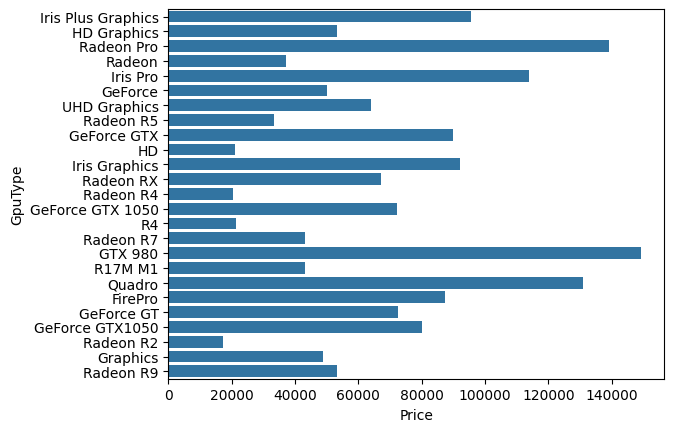

In [54]:
sns.barplot(df, y="GpuType", x="Price", errorbar=None)

In [55]:
df['GpuType'].value_counts()

GpuType
HD Graphics           592
GeForce GTX           204
GeForce               124
Radeon                 77
UHD Graphics           66
Radeon R5              42
Quadro                 31
HD                     29
GeForce GTX 1050       27
Radeon R7              25
Radeon RX              12
Iris Plus Graphics     10
GeForce GT              5
FirePro                 5
Radeon R4               5
Radeon R2               4
Iris Graphics           3
Radeon Pro              3
R4                      1
GTX 980                 1
R17M M1                 1
Iris Pro                1
GeForce GTX1050         1
Graphics                1
Radeon R9               1
Name: count, dtype: int64

In [56]:
def GPUNames(name):
    valid_names = {"HD Graphics", "GeForce GTX", "GeForce", "Radeone", "UHD Graphics", "Radeon R5", "Quadro", "HD","GeForce GTX 1050","Radeon R7","Radeon RX","Iris Plus Graphics"}
    if name not in valid_names:
        return "Others"
    else:
        return name

# Apply the function to the Company column
df["GpuType"] = df["GpuType"].apply(GPUNames)
df["GpuType"].value_counts()

GpuType
HD Graphics           592
GeForce GTX           204
GeForce               124
Others                109
UHD Graphics           66
Radeon R5              42
Quadro                 31
HD                     29
GeForce GTX 1050       27
Radeon R7              25
Radeon RX              12
Iris Plus Graphics     10
Name: count, dtype: int64

RAM

In [57]:
df["Ram"].value_counts()

Ram
8GB     601
4GB     365
16GB    194
6GB      40
12GB     25
2GB      22
32GB     17
64GB      3
24GB      3
1GB       1
Name: count, dtype: int64

In [58]:
# Changing data type of Ram column to numeric
df["RamGB"]=df["Ram"].str.extract('(\d+)').astype(int)
df["RamGB"].value_counts()

RamGB
8     601
4     365
16    194
6      40
12     25
2      22
32     17
64      3
24      3
1       1
Name: count, dtype: int64

<Axes: xlabel='RamGB', ylabel='Price'>

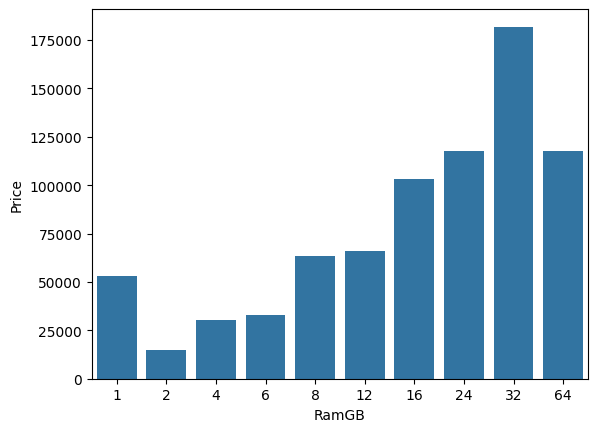

In [59]:
sns.barplot(df, y="Price", x="RamGB", errorbar=None)

In [60]:
q1=df.describe()["RamGB"]["25%"]
q3=df.describe()["RamGB"]["75%"]
IQR=q3-q1
ll=q1-(1.5*IQR)
ul=q3+(1.5*IQR)
df["RamGB"]=df["RamGB"].clip(ll,ul)
df["RamGB"].value_counts()

RamGB
8     601
4     365
14    217
6      40
12     25
2      22
1       1
Name: count, dtype: int64

In [61]:
df["RamGB"]=df["RamGB"].replace(1,2)
df["RamGB"].value_counts()

RamGB
8     601
4     365
14    217
6      40
12     25
2      23
Name: count, dtype: int64

CpuFrequency

<Axes: xlabel='CpuFrequencyGHz', ylabel='Count'>

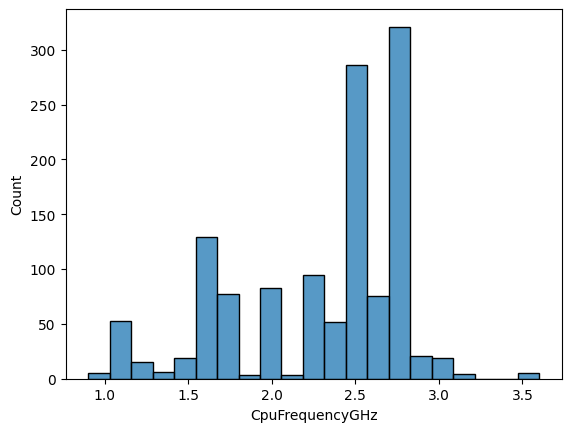

In [62]:
sns.histplot(df["CpuFrequencyGHz"])

<Axes: xlabel='CpuFrequencyGHz', ylabel='Count'>

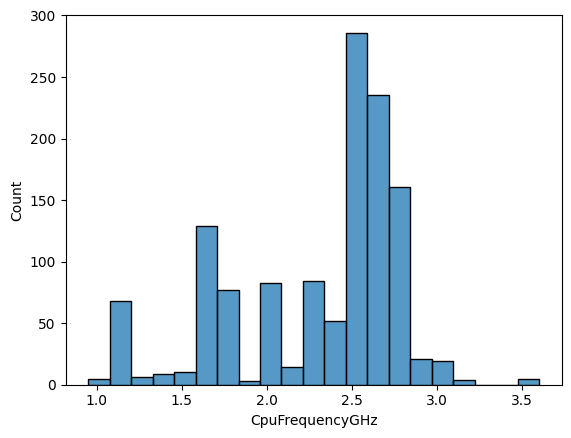

In [63]:
q1=df.describe()["CpuFrequencyGHz"]["25%"]
q3=df.describe()["CpuFrequencyGHz"]["75%"]
IQR=q3-q1
ll=q1-(1.5*IQR)
ul=q3+(1.5*IQR)
df["CpuFrequencyGHz"]=df["CpuFrequencyGHz"].clip(ll,ul)
sns.histplot(df["CpuFrequencyGHz"])

In [64]:
df["CpuFrequencyGHz"].unique()

array([2.3 , 1.8 , 2.5 , 2.7 , 3.1 , 3.  , 2.2 , 1.6 , 2.  , 2.8 , 1.2 ,
       2.9 , 2.4 , 1.5 , 1.9 , 1.44, 1.1 , 1.3 , 2.6 , 3.6 , 3.2 , 1.  ,
       2.1 , 0.95, 1.92])

In [65]:
correlaton_matrix=df.corr(numeric_only=True)
correlaton_matrix["Price"].sort_values(ascending=False)

Price              1.000000
RamGB              0.715405
Length             0.558603
Breadth            0.556389
PPI                0.487309
CpuFrequencyGHz    0.428473
WeightKg           0.174622
Inches             0.042705
Name: Price, dtype: float64

Storage device

In [66]:
df["StorageDevice"].value_counts()

StorageDevice
SSD              822
HDD              367
Flash Storage     71
Hybrid            10
Name: count, dtype: int64

In [67]:
df["StorageDevice"].unique()

array(['SSD', 'Flash Storage', 'HDD', 'Hybrid', nan], dtype=object)

In [68]:
df["StorageDevice"]=df["StorageDevice"].fillna(df["StorageDevice"].mode()[0])
df["StorageDevice"].unique()

array(['SSD', 'Flash Storage', 'HDD', 'Hybrid'], dtype=object)

<Axes: xlabel='StorageDevice', ylabel='Price'>

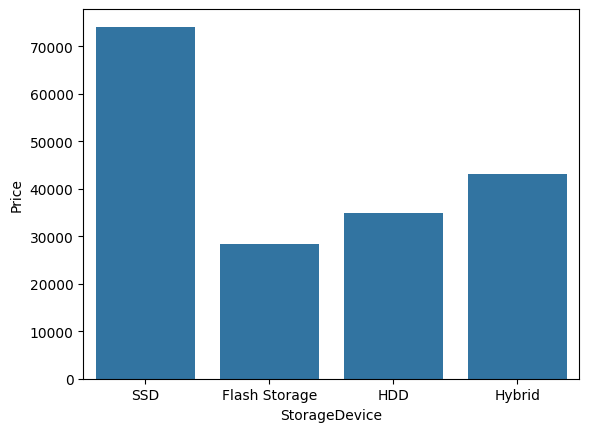

In [69]:
sns.barplot(df, y="Price", x="StorageDevice", errorbar=None)

Price of Laptop

<Axes: xlabel='Price', ylabel='Count'>

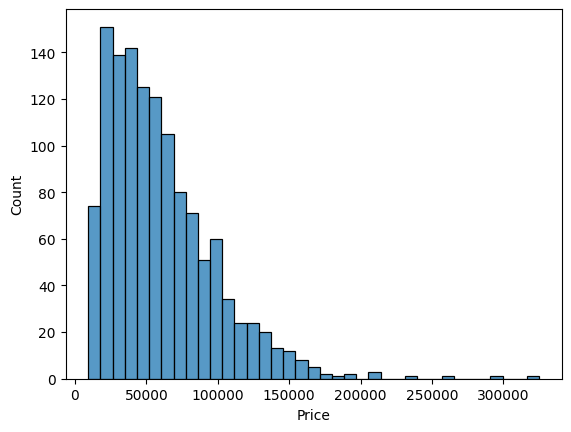

In [70]:
sns.histplot(df["Price"])

In [71]:
df["Price"].describe()

count      1271.000000
mean      59999.519339
std       37345.166683
min        9270.720000
25%       31914.720000
50%       52161.120000
75%       79360.295000
max      324954.720000
Name: Price, dtype: float64

In [72]:
q1=df.describe()["Price"]["25%"]
q3=df.describe()["Price"]["75%"]
IQR=q3-q1
ll=q1-(1.5*IQR)
ul=q3+(1.5*IQR)
df["Price"]=df["Price"].clip(ll,ul)
df["Price"].describe()

count      1271.000000
mean      59206.614508
std       34362.683641
min        9270.720000
25%       31914.720000
50%       52161.120000
75%       79360.295000
max      150528.657500
Name: Price, dtype: float64

<Axes: xlabel='Price', ylabel='Count'>

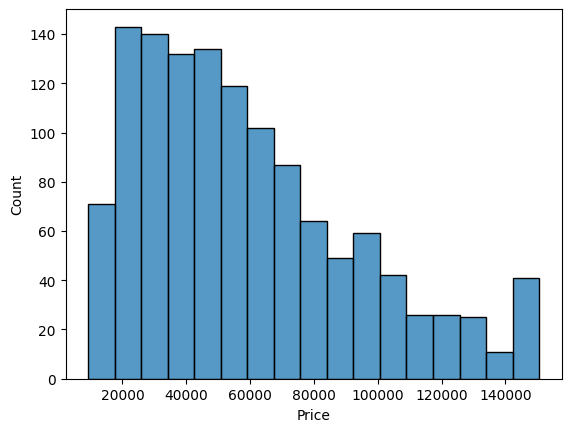

In [73]:
sns.histplot(df["Price"])

CpuCore

In [74]:
df["CpuCore"].value_counts()

CpuCore
Core i7              515
Core i5              410
Core i3              134
Others                98
Celeron Dual Core     79
Core M                19
A12-Series             8
Ryzen                  4
Xeon                   4
Name: count, dtype: int64

In [75]:
df["Memory"].value_counts()

Memory
256GB    496
1TB      233
128GB    173
512GB    138
500GB    130
32GB      43
2TB       16
64GB      15
1.0TB     10
16GB      10
180GB      4
240GB      1
8GB        1
508GB      1
Name: count, dtype: int64

In [76]:
df["MemoryGB"]=df["Memory"].str.strip().replace("1.0TB","1TB").replace("1TB","1000GB").replace("2TB","2000GB").replace('508GB','500GB').replace('8GB','16GB').replace('240GB','256GB')

In [77]:
df["Memory_GB"]=df["MemoryGB"].str.extract(r'(\d+)').astype(int)
df["Memory_GB"].value_counts()

Memory_GB
256     497
1000    243
128     173
512     138
500     131
32       43
2000     16
64       15
16       11
180       4
Name: count, dtype: int64

<Axes: xlabel='Memory_GB', ylabel='Price'>

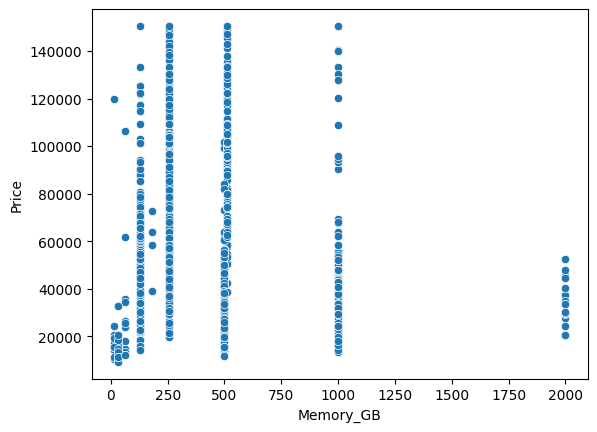

In [78]:
sns.scatterplot(df, x="Memory_GB", y="Price")

correlaton matrix

In [79]:
correlaton_matrix=df.corr(numeric_only=True)
correlaton_matrix["Price"].sort_values(ascending=False)

Price              1.000000
RamGB              0.739207
Length             0.555188
Breadth            0.554262
PPI                0.505234
CpuFrequencyGHz    0.441170
WeightKg           0.151847
Inches             0.026349
Memory_GB         -0.154695
Name: Price, dtype: float64

In [80]:
df.columns

Index(['Company', 'Laptop_Type', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Pixels', 'DisplayType',
       'Length', 'Breadth', 'PPI', 'Cpu_Manufacturer', 'CpuCoreSeries',
       'CpuFrequencyGHz', 'GpuManufacturer', 'GpuType', 'StorageDevice',
       'Display_Type', 'Display', 'CompanyName', 'WeightKg', 'CpuCore',
       'RamGB', 'MemoryGB', 'Memory_GB'],
      dtype='object')

In [81]:
df.drop(columns=['Company','Memory', 'Inches', 'ScreenResolution', 'Cpu', 'Ram','Gpu', 'Weight', 'Pixels', 'DisplayType','Length', 'Breadth', 'PPI','CpuCoreSeries','WeightKg','MemoryGB','Memory_GB','Display_Type'],axis=1,inplace=True)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1271 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Laptop_Type       1271 non-null   object 
 1   OpSys             1271 non-null   object 
 2   Price             1271 non-null   float64
 3   Cpu_Manufacturer  1271 non-null   object 
 4   CpuFrequencyGHz   1271 non-null   float64
 5   GpuManufacturer   1271 non-null   object 
 6   GpuType           1271 non-null   object 
 7   StorageDevice     1271 non-null   object 
 8   Display           1271 non-null   object 
 9   CompanyName       1271 non-null   object 
 10  CpuCore           1271 non-null   object 
 11  RamGB             1271 non-null   int64  
dtypes: float64(2), int64(1), object(9)
memory usage: 129.1+ KB


In [83]:
df.isnull().sum()

Laptop_Type         0
OpSys               0
Price               0
Cpu_Manufacturer    0
CpuFrequencyGHz     0
GpuManufacturer     0
GpuType             0
StorageDevice       0
Display             0
CompanyName         0
CpuCore             0
RamGB               0
dtype: int64

In [158]:
# Splitting the data into independent variables (X) and dependent variable (y)
X = df.drop(columns='Price')
X.columns

Index(['Laptop_Type', 'OpSys', 'Cpu_Manufacturer', 'CpuFrequencyGHz',
       'GpuManufacturer', 'GpuType', 'StorageDevice', 'Display', 'CompanyName',
       'CpuCore', 'RamGB'],
      dtype='object')

In [159]:
y = df["Price"]
y.head()

0     71378.68
1     47895.52
2     30636.00
3    135195.34
4     96095.81
Name: Price, dtype: float64

In [160]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [161]:
categorical_processor=Pipeline(
steps=[
("imputation_constant",SimpleImputer(fill_value="missing",strategy="most_frequent")),
("OneHotEncoder",OneHotEncoder(handle_unknown="ignore"))
])
categorical_processor

Pipeline(steps=[('imputation_constant',
                 SimpleImputer(fill_value='missing', strategy='most_frequent')),
                ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'))])

In [162]:
numeric_processor=Pipeline(
steps=[
("imputation",SimpleImputer()),
("StandardScaler",StandardScaler())
])
numeric_processor

Pipeline(steps=[('imputation', SimpleImputer()),
                ('StandardScaler', StandardScaler())])

In [163]:
categorical_columns = X.select_dtypes(include='object')
categorical_columns.columns

Index(['Laptop_Type', 'OpSys', 'Cpu_Manufacturer', 'GpuManufacturer',
       'GpuType', 'StorageDevice', 'Display', 'CompanyName', 'CpuCore'],
      dtype='object')

In [164]:
numerical_columns = X.select_dtypes(exclude='object')
numerical_columns.columns

Index(['CpuFrequencyGHz', 'RamGB'], dtype='object')

In [165]:
#Combining processing Techniques
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(
    transformers=[
        ("categorical",categorical_processor,categorical_columns.columns),
        ("numeric",numeric_processor,numerical_columns.columns)],remainder='passthrough')
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('categorical',
                                 Pipeline(steps=[('imputation_constant',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='most_frequent')),
                                                 ('OneHotEncoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['Laptop_Type', 'OpSys', 'Cpu_Manufacturer', 'GpuManufacturer',
       'GpuType', 'StorageDevice', 'Display', 'CompanyName', 'CpuCore'],
      dtype='object')),
                                ('numeric',
                                 Pipeline(steps=[('imputation',
                                                  SimpleImputer()),
                                                 ('StandardScaler',
                                                  StandardScaler())]),
                                 Index(['CpuFrequencyGHz', 'RamGB'], dtype='object'))])

In [166]:
from sklearn.model_selection import train_test_split

# Splitting the data for training and testing the model
x_train,x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [124]:
%%capture
!pip install xgboost

In [167]:
#Combining processing Techniques

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

final=make_pipeline(preprocessor,XGBRegressor())

final


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  Pipeline(steps=[('imputation_constant',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='most_frequent')),
                                                                  ('OneHotEncoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Laptop_Type', 'OpSys', 'Cpu_Manufacturer', 'GpuManufacturer',
       'GpuType', 'Stora...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

In [168]:
final.fit(x_train,y_train)

#Predict on the test data
y_pred = final.predict(x_test)

#Calculate MSE and RMSE
MSE = mean_squared_error(y_test, y_pred)
RMSE = MSE ** 0.5

# Print RMSE
print("RMSE:", RMSE)

RMSE: 13523.177329460608


Root Mean Square Error for the model:
XGBRegressor = 13523,
RandomForestRegressor = 14212,
LinearRegression = 15879,
KNeighborsRegressor  =16460,
DecisionTreeRegressor = 17274,
SVR = 32094.

In [169]:
# creating Gradio Application
%%capture
!pip install gradio

In [150]:
X.columns

Index(['Laptop_Type', 'OpSys', 'Cpu_Manufacturer', 'CpuFrequencyGHz',
       'GpuManufacturer', 'GpuType', 'StorageDevice', 'Display', 'CompanyName',
       'CpuCore', 'RamGB'],
      dtype='object')

In [170]:
import gradio as gr
def prediction_Price(Laptop_Type, OpSys,Cpu_Manufacturer,  CpuFrequencyGHz,
       GpuManufacturer, GpuType, StorageDevice,Display,
       CompanyName, CpuCore, RamGB):
  inputs=pd.DataFrame([[Laptop_Type, OpSys, Cpu_Manufacturer, CpuFrequencyGHz,
       GpuManufacturer, GpuType, StorageDevice,Display,
       CompanyName, CpuCore, RamGB]],columns=['Laptop_Type', 'OpSys','Cpu_Manufacturer',  'CpuFrequencyGHz',
       'GpuManufacturer', 'GpuType', 'StorageDevice','Display',
       'CompanyName', 'CpuCore', 'RamGB'])

  return final.predict(inputs)[0]


In [154]:
y_test.head(1)

1285    79866.72
Name: Price, dtype: float64

In [153]:
x_test.head(1)

,Laptop_Type,OpSys,Cpu_Manufacturer,CpuFrequencyGHz,GpuManufacturer,GpuType,StorageDevice,Display,CompanyName,CpuCore,RamGB
1285,2 in 1 Convertible,Windows 10,Intel,2.5,Intel,HD Graphics,SSD,IPS Panel,Lenovo,Core i7,14


In [ ]:

Laptop_Type = gr.Dropdown(label="Laptop Type", choices=['Ultrabook', 'Notebook', 'Gaming', '2 in 1 Convertible', 'Workstation', 'Netbook'])
CompanyName = gr.Dropdown(label="Company", choices=['Apple', 'HP', 'Acer', 'Asus', 'Dell', 'Lenovo', 'MSI','Razer', 'Others'])
OpSys = gr.Dropdown(label="OpSys", choices=['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Windows 10 S', 'Chrome OS', 'Windows 7'])
Cpu_Manufacturer = gr.Dropdown(label="Cpu Manufacturer", choices=['Intel', 'AMD'])
CpuCore = gr.Dropdown(label="Cpu(Core/series)", choices=['Core i5', 'Core i7', 'Core i3', 'Core M','Celeron Dual Core', 'Ryzen', 'Xeon', 'A12-Series''Others',])
CpuFrequencyGHz = gr.Number(label="Cpu Frequency(Between 0.0 to 3.5)GHz")
GpuManufacturer = gr.Dropdown(label="Gpu Manufacturer", choices=['Intel', 'AMD', 'Nvidia'])
GpuType = gr.Dropdown(label="Gpu Type", choices=['Iris Plus Graphics', 'HD Graphics', 'GeForce',
       'UHD Graphics', 'Radeon R5', 'GeForce GTX', 'HD', 'Radeon RX',
       'GeForce GTX 1050', 'Radeon R7', 'Quadro','Others'])
RamGB = gr.Dropdown(label="Ram(GB)",choices=[ 2, 4,  6,  8, 12, 14])
StorageDevice = gr.Dropdown(label="Storage Device", choices=['SSD', 'Flash Storage', 'HDD', 'Hybrid'])
Display = gr.Dropdown(label="Display Type", choices=['IPS Panel', 'Full HD', 'IPS Panel Full HD', 'Touchscreen','K Ultra HD'])


inputs = [Laptop_Type, OpSys,Cpu_Manufacturer,  CpuFrequencyGHz,
       GpuManufacturer, GpuType, StorageDevice,Display,
       CompanyName, CpuCore, RamGB]

outputs = gr.Number(label="Prediction Price")

app = gr.Interface(fn=prediction_Price, inputs=inputs, outputs=outputs, title="Prediction Price of a Laptop")

app.launch(debug=True)


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://3fdbee8feff432978c.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
